# Step 4: Model Interpretation

Use feature importance and SHAP values to identify which molecular features
most influence binding affinity predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load data and models
X = pd.read_csv('../data/processed/features.csv')
target = pd.read_csv('../data/processed/target.csv')
y = target['pchembl_value'].values
desc_df = pd.read_csv('../data/processed/descriptors_only.csv')

metadata = joblib.load('../models/metadata.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')
best_model = joblib.load('../models/best_model.pkl')

# Recreate train/test split with same random state
y_binned = pd.cut(y, bins=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"Best model: {metadata['best_model']}")
print(f"Features: {X.shape[1]} ({len(desc_df.columns)} descriptors + {X.shape[1] - len(desc_df.columns)} fingerprint bits)")

Best model: XGBoost
Features: 2060 (12 descriptors + 2048 fingerprint bits)


## 4.1 Feature Importance (Tree-Based Models)

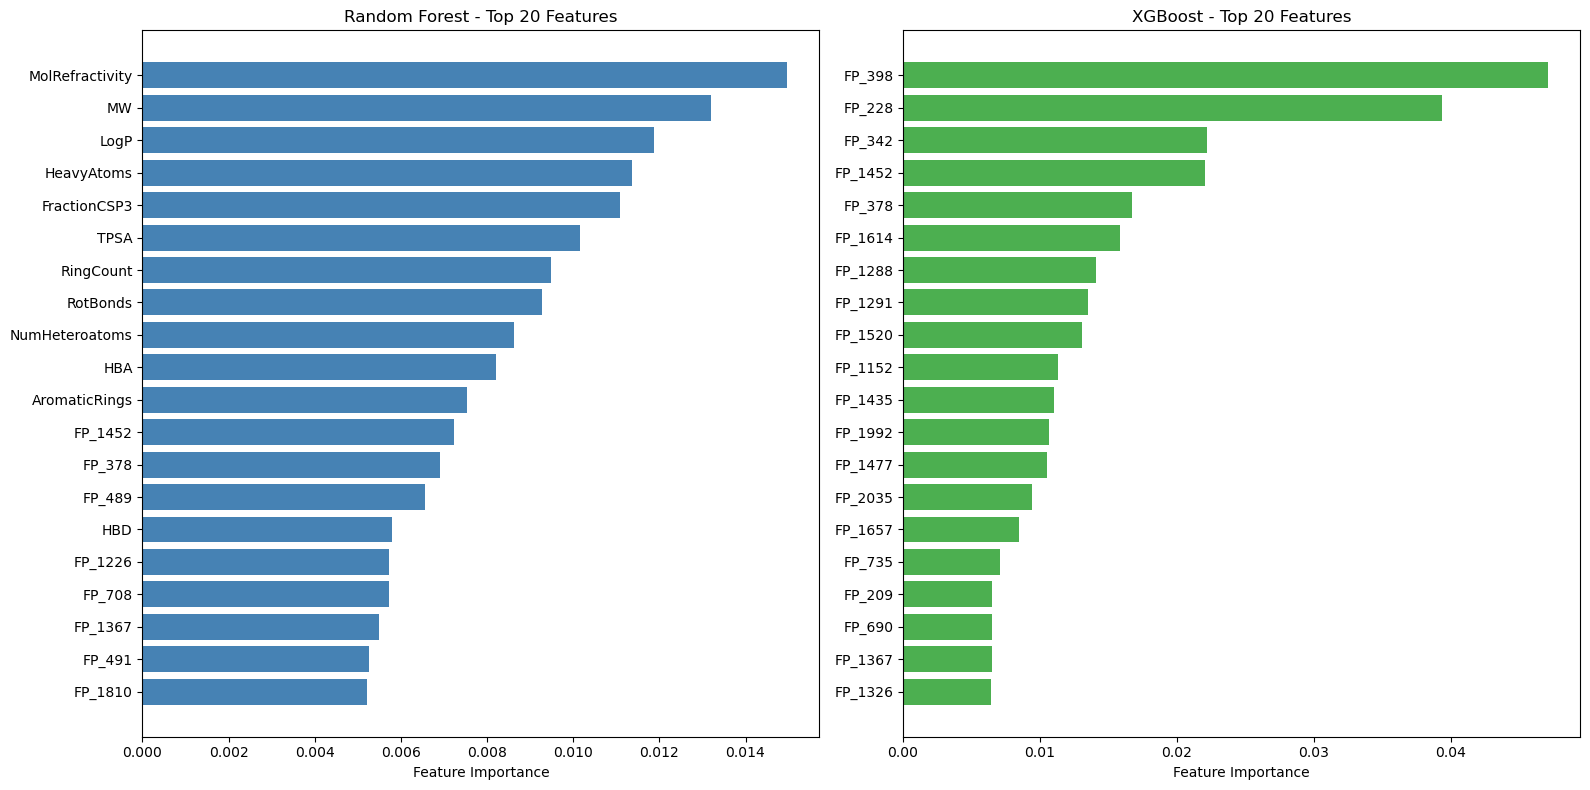

In [2]:
# Get feature importances from Random Forest and XGBoost
descriptor_cols = desc_df.columns.tolist()
fp_cols = [c for c in X.columns if c.startswith('FP_')]

def get_top_features(model, feature_names, n_top=20):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-n_top:][::-1]
    return pd.DataFrame({
        'Feature': [feature_names[i] for i in indices],
        'Importance': importances[indices]
    })

# Top 20 features for each model
rf_top = get_top_features(rf_model, X.columns.tolist())
xgb_top = get_top_features(xgb_model, X.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(len(rf_top)), rf_top['Importance'], color='steelblue')
axes[0].set_yticks(range(len(rf_top)))
axes[0].set_yticklabels(rf_top['Feature'])
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Random Forest - Top 20 Features')
axes[0].invert_yaxis()

axes[1].barh(range(len(xgb_top)), xgb_top['Importance'], color='#4CAF50')
axes[1].set_yticks(range(len(xgb_top)))
axes[1].set_yticklabels(xgb_top['Feature'])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost - Top 20 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Aggregate importance: descriptors vs fingerprints
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
desc_importance = rf_importances[descriptor_cols].sum()
fp_importance = rf_importances[fp_cols].sum()

print(f"RF Feature importance breakdown:")
print(f"  Physicochemical descriptors: {desc_importance:.4f} ({desc_importance/(desc_importance+fp_importance)*100:.1f}%)")
print(f"  Morgan fingerprint bits: {fp_importance:.4f} ({fp_importance/(desc_importance+fp_importance)*100:.1f}%)")

RF Feature importance breakdown:
  Physicochemical descriptors: 0.1215 (12.2%)
  Morgan fingerprint bits: 0.8785 (87.8%)


## 4.2 SHAP Analysis

In [4]:
# Use a subsample for SHAP (faster computation)
sample_size = min(500, len(X_test))
X_sample = X_test.iloc[:sample_size]

# SHAP for the best tree-based model
# Use TreeExplainer for RF/XGBoost
if metadata['best_model'] in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
else:
    # For SVR, use XGBoost for interpretation
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (500, 2060)


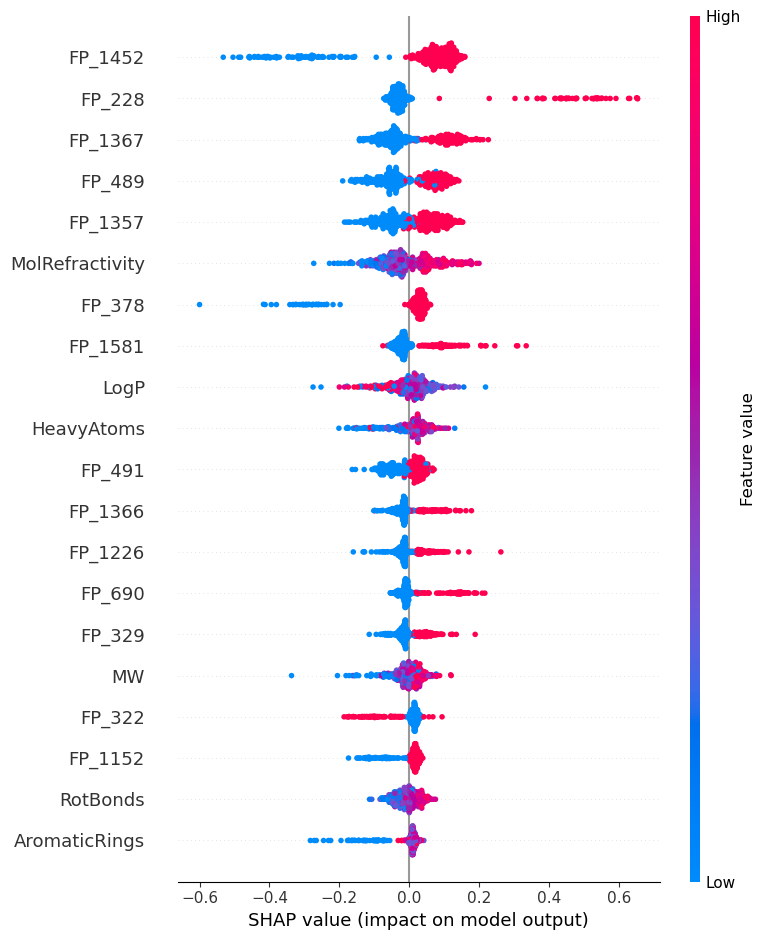

In [5]:
# SHAP Summary Plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

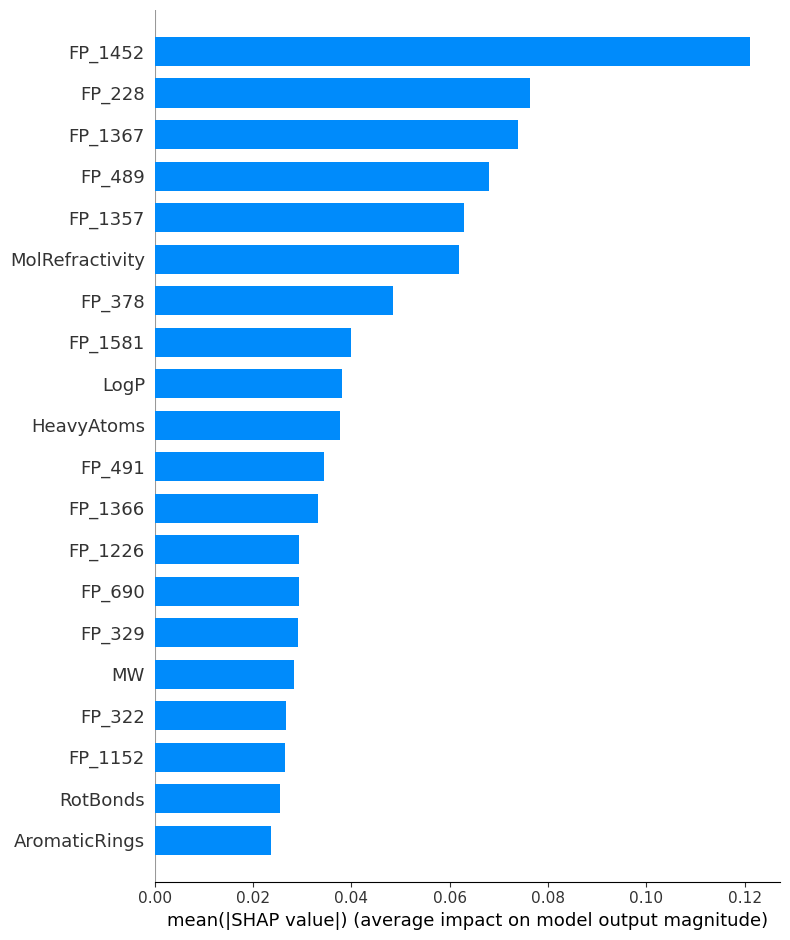

In [6]:
# SHAP bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig('../models/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

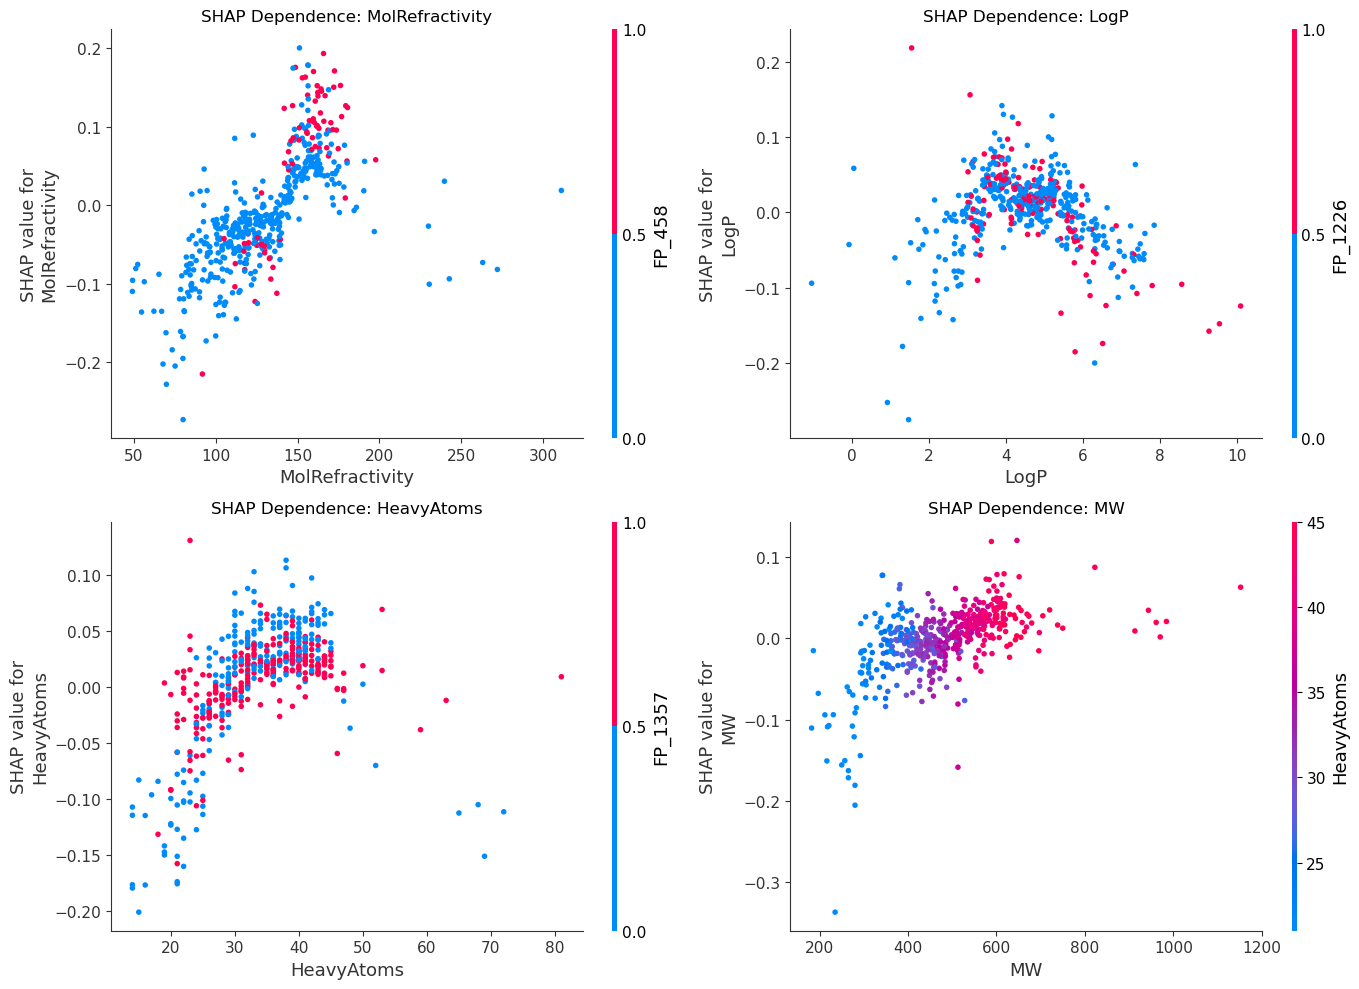

In [7]:
# SHAP dependence plots for top physicochemical descriptors
# Find top descriptors by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
desc_shap = pd.Series(mean_abs_shap, index=X.columns)
top_desc = desc_shap[descriptor_cols].nlargest(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_desc.index):
    feat_idx = list(X.columns).index(feat)
    plt.sca(axes[i])
    shap.dependence_plot(feat_idx, shap_values, X_sample, show=False, ax=axes[i])
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('../models/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Biological Interpretation

In [8]:
# Summarize key findings
print("="*60)
print("KEY FINDINGS - Feature Importance for EGFR Binding")
print("="*60)

# Top 10 features by mean |SHAP|
top_10_shap = desc_shap.nlargest(10)
print("\nTop 10 features by SHAP importance:")
for feat, val in top_10_shap.items():
    feat_type = 'Descriptor' if feat in descriptor_cols else 'Fingerprint bit'
    print(f"  {feat:25s} ({feat_type}): {val:.4f}")

print("\n" + "="*60)
print("BIOLOGICAL CONTEXT")
print("="*60)
print("""
Key observations for EGFR binding affinity:
- Molecular features like LogP, MW, and aromatic ring count reflect the 
  hydrophobic nature of the EGFR ATP-binding pocket.
- TPSA and hydrogen bond features relate to key interactions with 
  hinge region residues (Met793 in EGFR).
- Specific Morgan fingerprint bits correspond to substructural motifs
  commonly found in kinase inhibitors (e.g., quinazoline scaffolds).
- The balance between lipophilicity (LogP) and polar surface area (TPSA)
  is critical for both binding and drug-likeness.
""")

KEY FINDINGS - Feature Importance for EGFR Binding

Top 10 features by SHAP importance:
  FP_1452                   (Fingerprint bit): 0.1211
  FP_228                    (Fingerprint bit): 0.0763
  FP_1367                   (Fingerprint bit): 0.0738
  FP_489                    (Fingerprint bit): 0.0679
  FP_1357                   (Fingerprint bit): 0.0629
  MolRefractivity           (Descriptor): 0.0618
  FP_378                    (Fingerprint bit): 0.0484
  FP_1581                   (Fingerprint bit): 0.0400
  LogP                      (Descriptor): 0.0381
  HeavyAtoms                (Descriptor): 0.0378

BIOLOGICAL CONTEXT

Key observations for EGFR binding affinity:
- Molecular features like LogP, MW, and aromatic ring count reflect the 
  hydrophobic nature of the EGFR ATP-binding pocket.
- TPSA and hydrogen bond features relate to key interactions with 
  hinge region residues (Met793 in EGFR).
- Specific Morgan fingerprint bits correspond to substructural motifs
  commonly found 